In [62]:
import pandas as pd
import numpy as np
import re
import string
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [63]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv",)

In [64]:
fake["label"] = 0
true["label"] = 1

In [83]:
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1, random_state=42)
data.reset_index(drop=True, inplace=True)

In [66]:
print(data.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')


In [82]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [81]:
data["content"] = data["title"] + " " + data["text"]
data = data[data["content"].str.len() > 50]
data["content"] = data["content"].apply(clean_text)

In [69]:
X = data["content"]
y = data["label"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7, min_df=2, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

In [86]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.98625


In [73]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3997
           1       0.99      0.99      0.99      4003

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



In [74]:
pickle.dump(model, open("logistic_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [85]:
print(data["label"].value_counts())

label
1    20000
0    20000
Name: count, dtype: int64


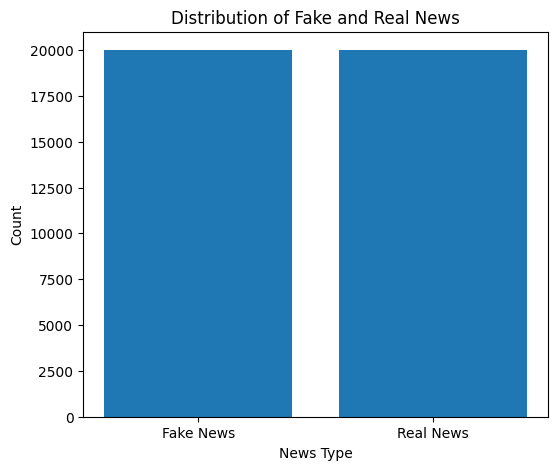

In [76]:
label_counts = data["label"].value_counts()
plt.figure(figsize=(6,5))
plt.bar(
    ["Fake News", "Real News"],
    label_counts.values
)
plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.show()

In [77]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[3939   58]
 [  52 3951]]


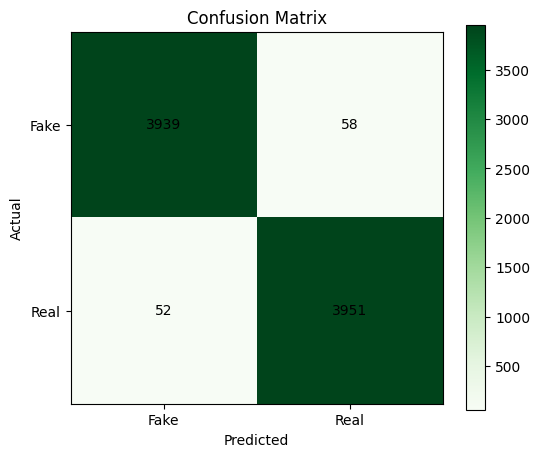

In [78]:
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Greens")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Fake", "Real"])
plt.yticks([0,1], ["Fake", "Real"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.show()

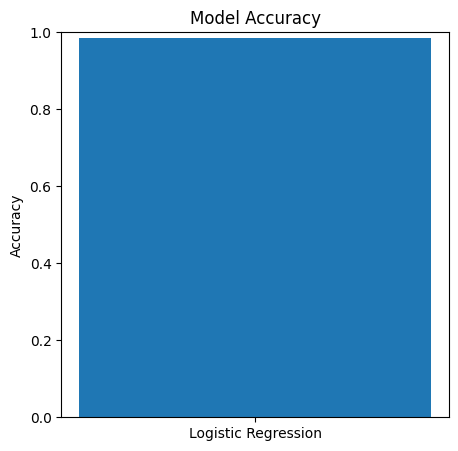

In [84]:
accuracy = accuracy_score(y_test, predictions)
plt.figure(figsize=(5,5))
plt.bar(["Logistic Regression"], [accuracy])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.show()